In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import joblib
import os, sys, logging
from model import predict_conditional, FlexibleNN

In [2]:
# Pallete for plotting
from matplotlib.colors import LinearSegmentedColormap
colorlist = [(0,0,0),(20,33,61),(252,163,17),(229,229,229),(255,255,255)]
colorlist = [[float(e)/255 for e in c] for c in colorlist]
mi_gradiente = LinearSegmentedColormap.from_list("mi_paleta", colorlist)

colorlist2 = [(244,241,222),(224,122,95),(61,64,91),(129,178,154),(242,204,143)]
colorlist2 = [[float(e)/255 for e in c] for c in colorlist2]
mi_gradiente2 = LinearSegmentedColormap.from_list("mi_paleta", colorlist2)


paleta = [{"name":"Ink Black","hex":"001219","rgb":[0,18,25],"cmyk":[100,28,0,90],"hsb":[197,100,10],"hsl":[197,100,5],"lab":[5,-4,-6]},
 {"name":"Dark Teal","hex":"005f73","rgb":[0,95,115],"cmyk":[100,17,0,55],"hsb":[190,100,45],"hsl":[190,100,23],"lab":[37,-16,-18]},
 {"name":"Dark Cyan","hex":"0a9396","rgb":[10,147,150],"cmyk":[93,2,0,41],"hsb":[181,93,59],"hsl":[181,88,31],"lab":[55,-30,-11]},
 {"name":"Pearl Aqua","hex":"94d2bd","rgb":[148,210,189],"cmyk":[30,0,10,18],"hsb":[160,30,82],"hsl":[160,41,70],"lab":[80,-24,4]},
 {"name":"Vanilla Custard","hex":"e9d8a6","rgb":[233,216,166],"cmyk":[0,7,29,9],"hsb":[45,29,91],"hsl":[45,60,78],"lab":[87,-2,27]},
 {"name":"Golden Orange","hex":"ee9b00","rgb":[238,155,0],"cmyk":[0,35,100,7],"hsb":[39,100,93],"hsl":[39,100,47],"lab":[71,22,75]},
 {"name":"Burnt Caramel","hex":"ca6702","rgb":[202,103,2],"cmyk":[0,49,99,21],"hsb":[30,99,79],"hsl":[30,98,40],"lab":[54,34,62]},
 {"name":"Rusty Spice","hex":"bb3e03","rgb":[187,62,3],"cmyk":[0,67,98,27],"hsb":[19,98,73],"hsl":[19,97,37],"lab":[44,48,55]},
 {"name":"Oxidized Iron","hex":"ae2012","rgb":[174,32,18],"cmyk":[0,82,90,32],"hsb":[5,90,68],"hsl":[5,81,38],"lab":[38,55,44]},
 {"name":"Brown Red","hex":"9b2226","rgb":[155,34,38],"cmyk":[0,78,75,39],"hsb":[358,78,61],"hsl":[358,64,37],"lab":[35,49,29]}]
colorlist3 = []
for p in paleta:
    colorlist3.append(p["rgb"])

colorlist3 = [[float(e)/255 for e in c] for c in colorlist3]
mi_gradiente3 = LinearSegmentedColormap.from_list("mi_paleta", colorlist3)

In [3]:
# Load the model
DEVICE = torch.device('cpu')
MODEL_FOLDER = os.path.join('.','models_folder')

encoder = joblib.load(os.path.join(MODEL_FOLDER, 'one_hot_encoder_models.joblib'))
# model = FlexibleNN(6, 128, "gauss", 0.0)
# model.load_state_dict(torch.load(os.path.join(MODEL_FOLDER,'best_statedict_gauss_128_128_128.pth'),map_location=DEVICE))

model = FlexibleNN(6, 128, "gauss", 0.0)
model.load_state_dict(torch.load(os.path.join(MODEL_FOLDER,'best_statedict_gauss_128_128_128_hole_3.pth'),map_location=DEVICE))
model.eval()
print('Theoretical models trained:', encoder.categories_)

Theoretical models trained: [array(['CDW-EIS', 'CTMC', 'Semiempiric_1985Rudd'], dtype=object)]


In [4]:
# Load the databases to check the metrics
from db_reader import read_all_databases

namelist = [os.path.join('.','dbs','Semiempiric_db', 'semiempiric_TCS_database_single_ionization_atoms_1985Rudd.csv'),
            os.path.join('.','dbs','ctmc', 'ctmc_TCS_database_single_ionization_hydrogen.csv'),
            os.path.join('.','dbs','CDWEIS', 'cdw-eis_TCS_database_single_ionization_atoms_except_Kr.csv')]


df =read_all_databases(namelist)

# --- Prepare the Data ---
df['log_E'] = np.log10(df['E_proj[keV/u]'])
df['log_sigma'] = np.log10(df['Cross_section[cm2]'])

# One-hot encode Theory_ID

# --- Data for the Conditional NN with Z_target = 1 ---
hyd_df = df[df['Z_target']==1]
theory_one_hot = encoder.transform(hyd_df[['Theory_ID']].values)
hyd_df.columns
hyd_df[hyd_df['Theory_ID'] == 'CDW-EIS']

,Z_ion,Z_target,E_proj[keV/u],Cross_section[cm2],Uncertainty[%],is_exp,Theory_ID,DOI,log_E,log_sigma
0,1,1,10.0,7.574000e-18,0,0,CDW-EIS,_,1.000000,-17.120675
1,1,1,20.0,6.336000e-17,0,0,CDW-EIS,_,1.301030,-16.198185
2,1,1,30.0,1.159000e-16,0,0,CDW-EIS,_,1.477121,-15.935917
3,1,1,40.0,1.415000e-16,0,0,CDW-EIS,_,1.602060,-15.849244
4,1,1,50.0,1.494000e-16,0,0,CDW-EIS,_,1.698970,-15.825649
...,...,...,...,...,...,...,...,...,...,...
1214,9,1,60000.0,4.255000e-17,0,0,CDW-EIS,_,4.778151,-16.371100
1215,9,1,70000.0,3.737000e-17,0,0,CDW-EIS,_,4.845098,-16.427477
1216,9,1,80000.0,3.343000e-17,0,0,CDW-EIS,_,4.903090,-16.475864
1217,9,1,90000.0,3.034000e-17,0,0,CDW-EIS,_,4.954243,-16.517984


# Testing energy interpolations

In [5]:
from scipy.interpolate import CubicSpline

In [6]:
splines = {}

for theory in ['CDW-EIS', 'CTMC']:
    splines[theory] = {}
    data_theory = hyd_df[hyd_df['Theory_ID'] == theory]
    for i in range(1,10):
        x = data_theory[data_theory['Z_ion'] == i]['log_E'].values
        y = data_theory[data_theory['Z_ion'] == i]['log_sigma'].values
        splines[theory][i] = CubicSpline(x, y, bc_type='natural')

In [7]:
def cubic_spline_model(spline_dict, theory, z_ion, energy):
    assert theory in spline_dict.keys(), f'theories allowed {spline_dict.keys()}'
    assert type(z_ion) == int, 'z_ion must be integer'
    x = np.log10(energy)
    y = spline_dict[theory][z_ion](x)
    return 10**y

def abs_err(y_pred, ground_truth):
    return np.abs(ground_truth-y_pred)

def rel_err(y_pred, ground_truth):
    return abs_err(y_pred, ground_truth)/np.abs(ground_truth)

/tmp/ipykernel_892253/3687064580.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = np.log10(energy)


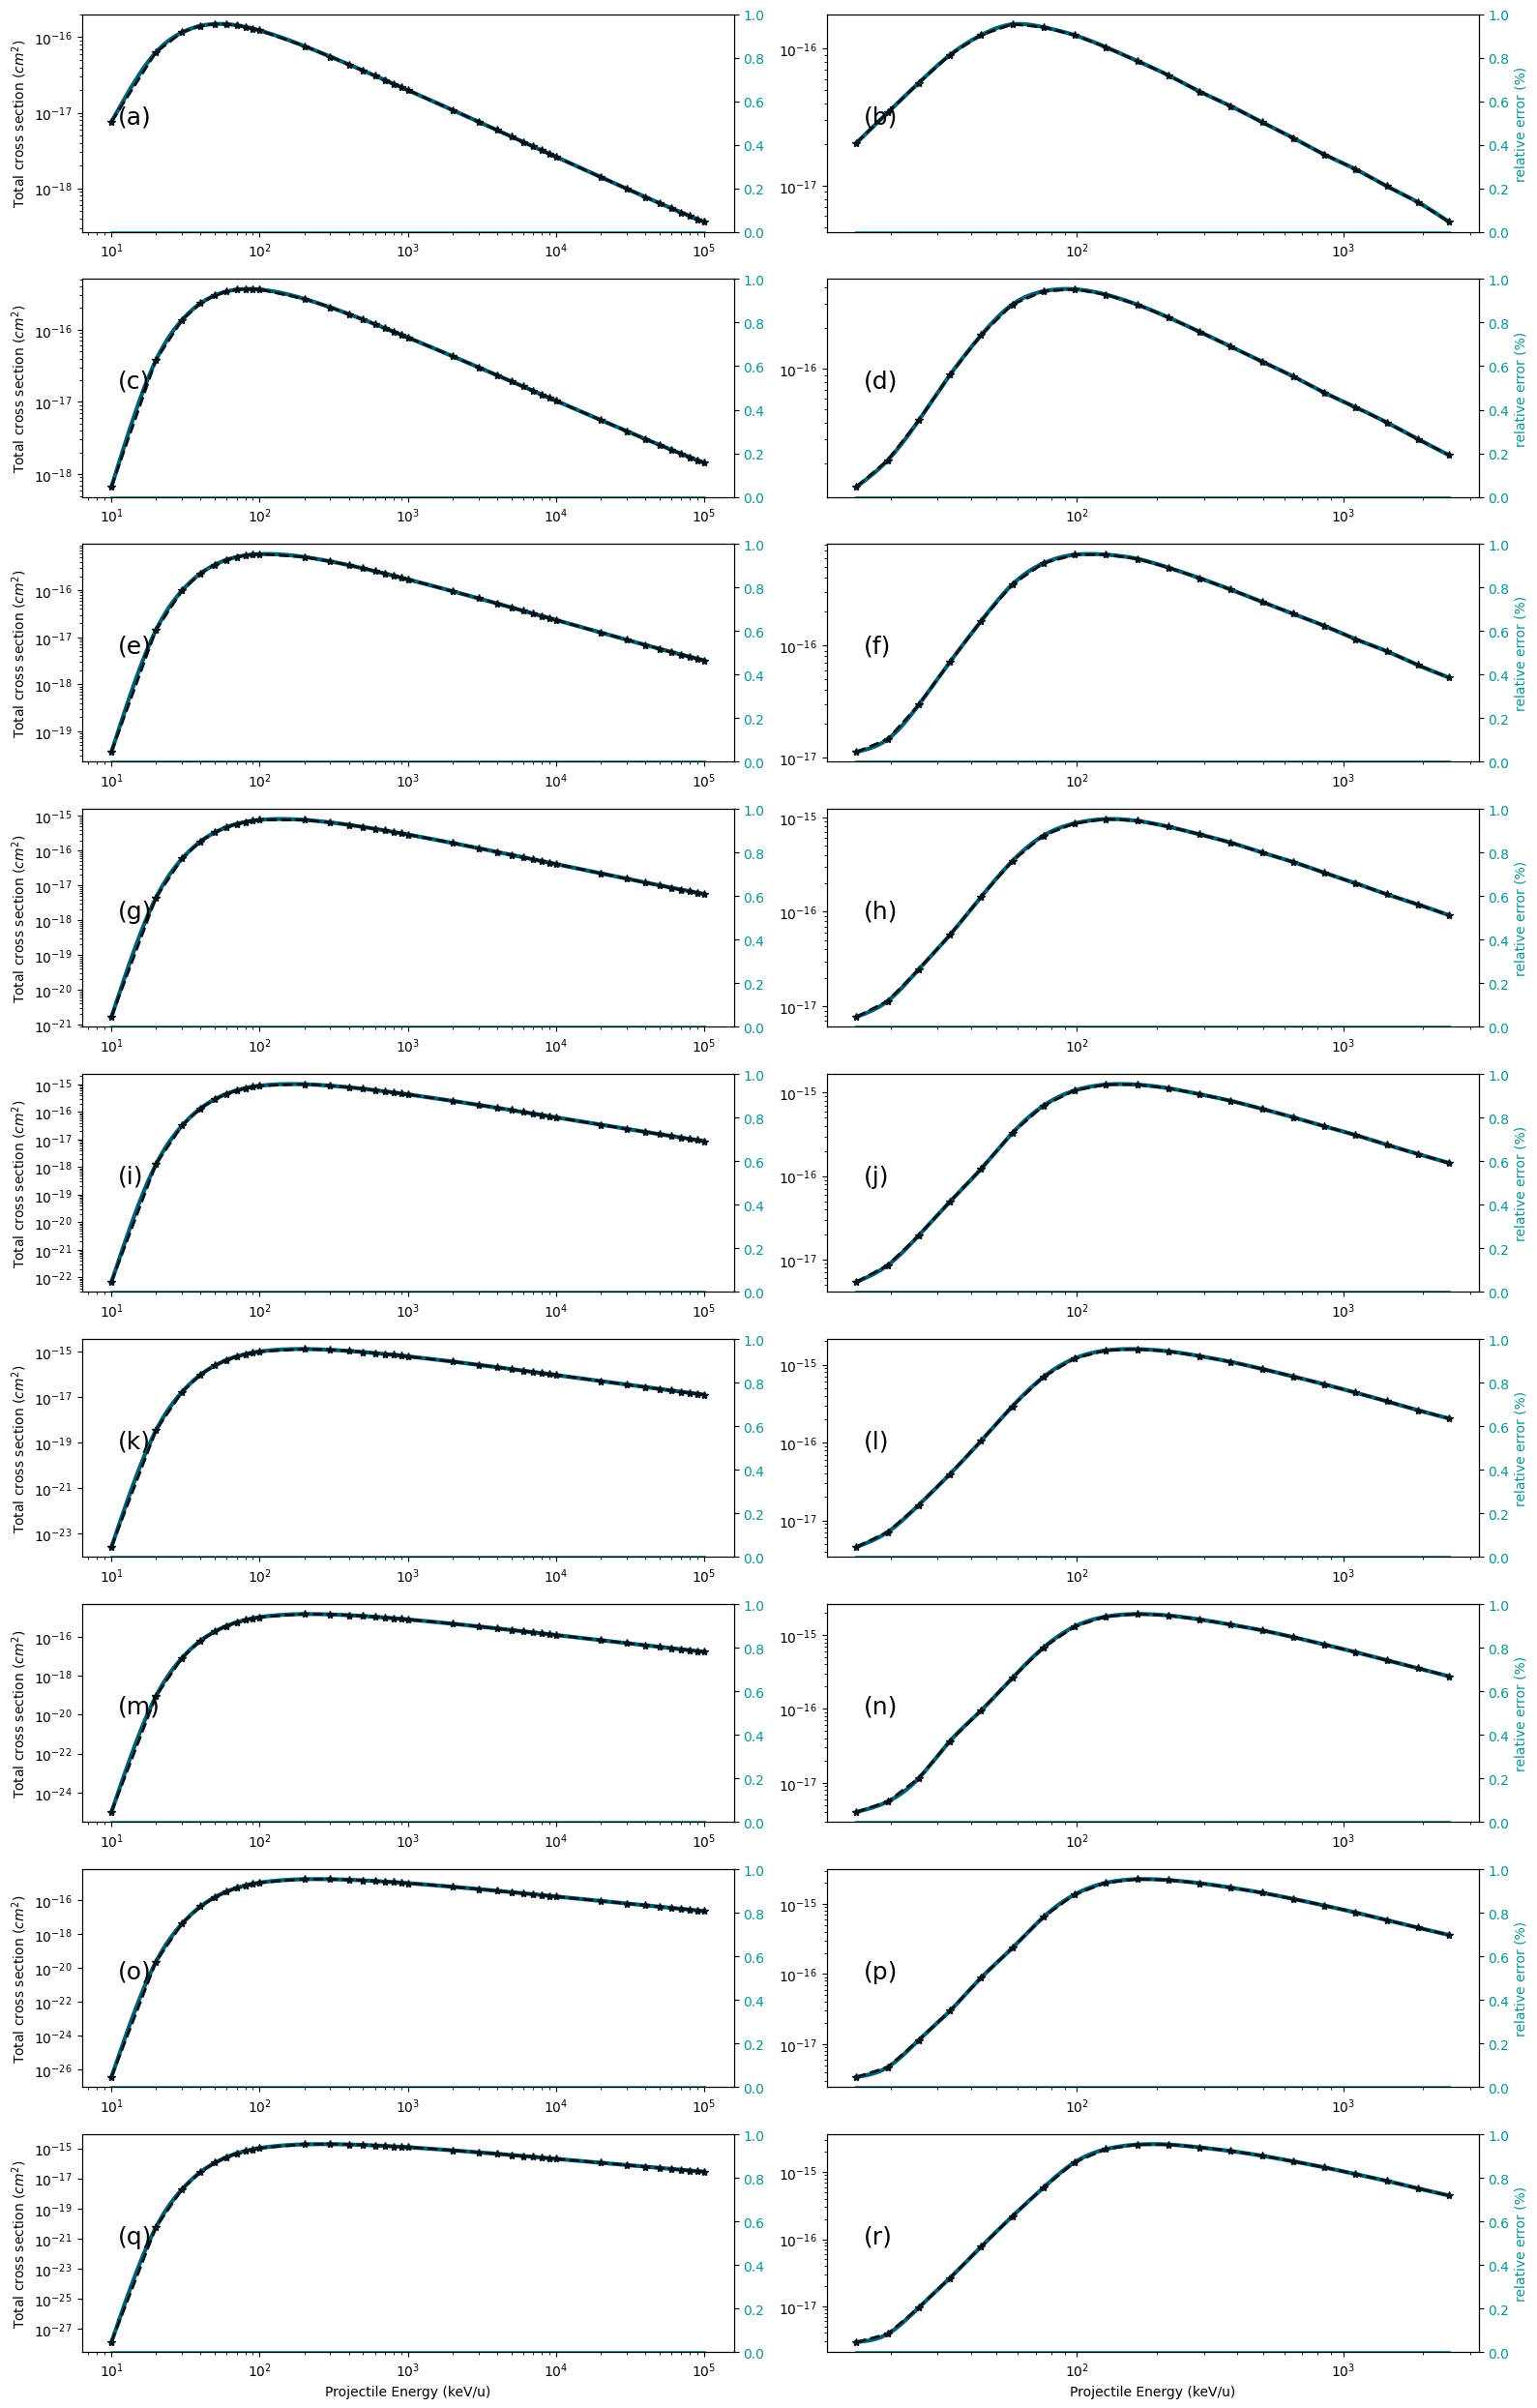

In [8]:
# Here we plot ground truth data vs real claculated data
labels_figs = ['(a)','(b)','(c)','(d)','(e)',
               '(f)','(g)','(h)','(i)','(j)',
               '(k)','(l)','(m)','(n)',
               '(o)','(p)','(q)','(r)',
               '(s)','(t)','(u)','(v)',]
df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)
fig, axes = plt.subplots(9,2, figsize=(16, 25))

idx_row = 0
for z_ion in range(1,10):
    idx_col = 0
    for theory in ['CDW-EIS', 'CTMC']:
        aux = hyd_df[hyd_df['Theory_ID'] == theory]
        x = aux[aux['Z_ion'] == z_ion]['E_proj[keV/u]'].values
        y = aux[aux['Z_ion'] == z_ion]['Cross_section[cm2]'].values
        y_pred = cubic_spline_model(splines, theory, z_ion, x)
        x_to_predict = torch.logspace(np.log10(np.min(x)),
                                        np.log10(np.max(x)),
                                        1000)
        y_pred_lp = cubic_spline_model(splines, theory, z_ion, x_to_predict).reshape(-1)
        error = rel_err(y, y_pred)*100

        axes[idx_row,idx_col].loglog(x_to_predict, y_pred_lp, lw = 3, 
                                        color= colorlist3[1], 
                                        label = f'MLP {theory}' )

        axes[idx_row,idx_col].loglog(x, y, '*--', lw = 2, color= colorlist3[0],
                                        label = f'Theory {theory}' )

        ax_right = axes[idx_row,idx_col].twinx()
        ax_right.semilogx(x, error, c = colorlist3[2], lw = 2)
        ax_right.fill_between(x, error,color = colorlist3[3], alpha = 0.5)
        
        ax_right.tick_params(axis='y', labelcolor=colorlist3[2])
        ax_right.set_ylim(0,1)
        ax_right.text(x.min()+1, 0.5, labels_figs[idx_col+idx_row*2], fontsize=18)

        # axes[idx_row,idx_col].legend()
        idx_col += 1
    ax_right.set_ylabel('relative error (%)', color=colorlist3[2])
    axes[idx_row,0].set_ylabel(r'Total cross section ($cm^2$)' )
    idx_row +=1
    axes[8,0].set_xlabel('Projectile Energy (keV/u)')
    axes[8,1].set_xlabel('Projectile Energy (keV/u)')
fig.tight_layout()
plt.savefig('./performance_cubic.png')


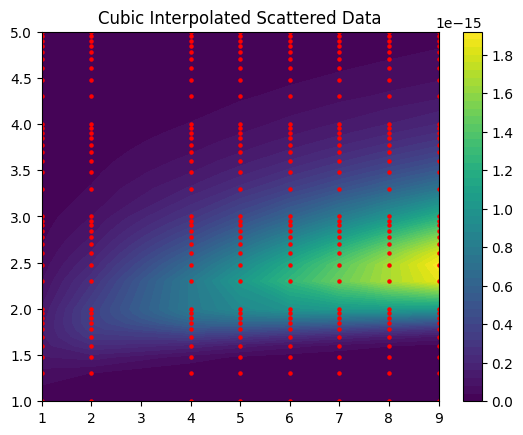

In [9]:
import numpy as np
from scipy.interpolate import griddata, RectBivariateSpline
import matplotlib.pyplot as plt
df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)

aux = hyd_df[hyd_df['Theory_ID'] == 'CDW-EIS']
aux = aux[aux['Z_ion']!=3]
x_hole = aux['Z_ion'].values
y_hole = np.log10(aux['E_proj[keV/u]'].values)
z_hole = aux['Cross_section[cm2]'].values

# 1. Define your scattered data points (Pi) and values (Zi)
# Pi is a N x 2 array of coordinates (x, y)
# Zi is a 1D array of values at those coordinates
points = np.vstack([x_hole,y_hole]).T
values = z_hole

# 2. Define the target regular grid for the output
grid_x, grid_y = np.meshgrid(np.unique(x_hole), np.unique(y_hole))
# 3. Perform cubic interpolation using griddata
grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

# Optional: Visualize the result
plt.contourf(grid_x, grid_y, grid_z, 50, cmap='viridis')
plt.colorbar()
plt.scatter(points[:, 0], points[:, 1], color='red', s=5)
plt.title("Cubic Interpolated Scattered Data")
plt.show()

In [10]:
from scipy.interpolate import bisplrep, bisplev
nudos = bisplrep(x_hole, y_hole, z_hole, kx=3, ky=3, s = 0)
n_coeficientes = len(nudos[2])
print(f"La cantidad de coeficientes es: {n_coeficientes}")

La cantidad de coeficientes es: 300


/tmp/ipykernel_892253/4079326144.py:2: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=3,3 nx,ny=16,29 m=296 fp=0.000000 s=0.000000
  nudos = bisplrep(x_hole, y_hole, z_hole, kx=3, ky=3, s = 0)


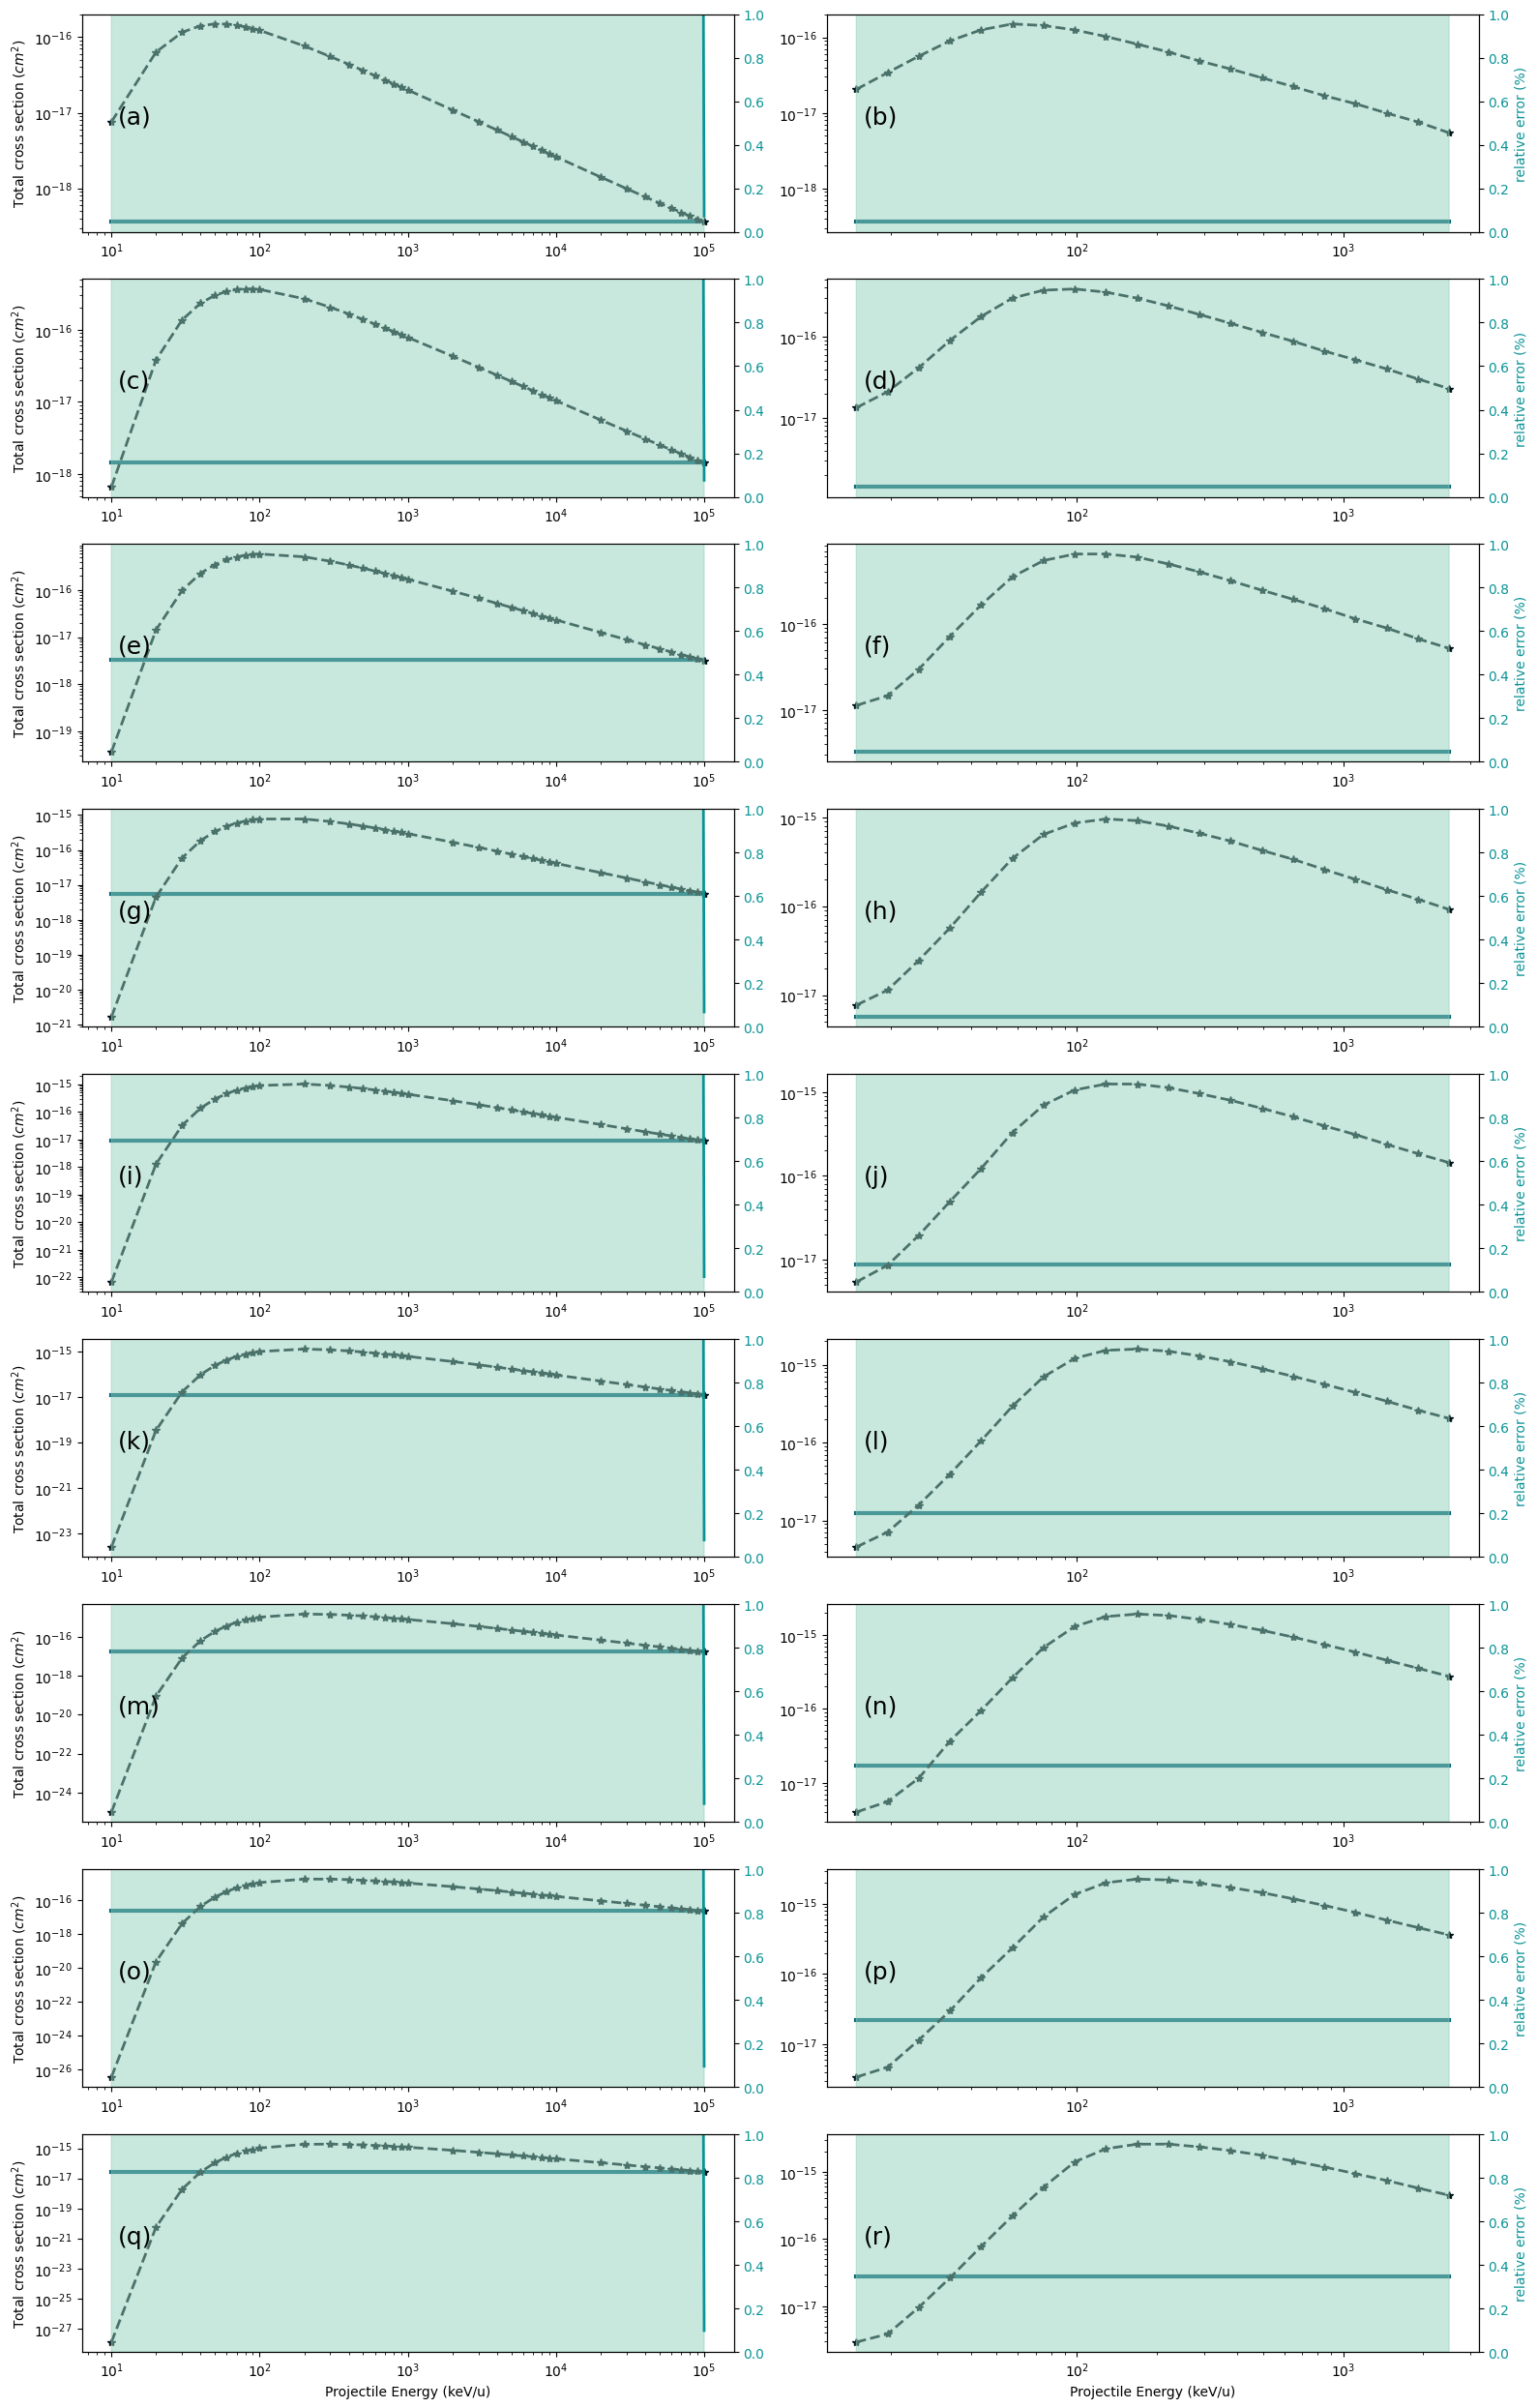

In [11]:
# Here we plot ground truth data vs real claculated data
labels_figs = ['(a)','(b)','(c)','(d)','(e)',
               '(f)','(g)','(h)','(i)','(j)',
               '(k)','(l)','(m)','(n)',
               '(o)','(p)','(q)','(r)',
               '(s)','(t)','(u)','(v)',]

df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)

fig, axes = plt.subplots(9,2, figsize=(16, 25))

idx_row = 0
for z_ion in range(1,10):
    idx_col = 0
    for theory in ['CDW-EIS', 'CTMC']:
        aux = hyd_df[hyd_df['Theory_ID'] == theory]
        x = aux[aux['Z_ion'] == z_ion]['E_proj[keV/u]'].values
        y = aux[aux['Z_ion'] == z_ion]['Cross_section[cm2]'].values
        y_pred = bisplev(z_ion, x, nudos)
        x_to_predict = np.linspace(np.min(x),
                                        np.max(x),
                                        1000)
        y_pred_lp = bisplev(z_ion, x_to_predict, nudos)
        error = rel_err(y, y_pred)*100

        axes[idx_row,idx_col].loglog(x_to_predict, y_pred_lp, lw = 3, 
                                        color= colorlist3[1], 
                                        label = f'MLP {theory}' )

        axes[idx_row,idx_col].loglog(x, y, '*--', lw = 2, color= colorlist3[0],
                                        label = f'Theory {theory}' )

        ax_right = axes[idx_row,idx_col].twinx()
        ax_right.semilogx(x, error, c = colorlist3[2], lw = 2)
        ax_right.fill_between(x, error,color = colorlist3[3], alpha = 0.5)
        
        ax_right.tick_params(axis='y', labelcolor=colorlist3[2])
        ax_right.set_ylim(0,1)
        ax_right.text(x.min()+1, 0.5, labels_figs[idx_col+idx_row*2], fontsize=18)

        # axes[idx_row,idx_col].legend()
        idx_col += 1
    ax_right.set_ylabel('relative error (%)', color=colorlist3[2])
    axes[idx_row,0].set_ylabel(r'Total cross section ($cm^2$)' )
    idx_row +=1
    axes[8,0].set_xlabel('Projectile Energy (keV/u)')
    axes[8,1].set_xlabel('Projectile Energy (keV/u)')
fig.tight_layout()
plt.savefig('./performance_cubic.png')


# Bicubic splines (Holes $Z_P=3$)

In [73]:
from scipy.interpolate import SmoothBivariateSpline
# --- Data for the Conditional NN with Z_target = 1 ---
from db_reader import read_all_databases

namelist = [os.path.join('.','dbs','Semiempiric_db', 'semiempiric_TCS_database_single_ionization_atoms_1985Rudd.csv'),
            os.path.join('.','dbs','ctmc', 'ctmc_TCS_database_single_ionization_hydrogen.csv'),
            os.path.join('.','dbs','CDWEIS', 'cdw-eis_TCS_database_single_ionization_atoms_except_Kr.csv')]

df =read_all_databases(namelist)

# One-hot encode Theory_ID
# --- Data for the Conditional NN with Z_target = 1 ---

hyd_df = df[df['Z_target']==1]
theory_one_hot = encoder.transform(hyd_df[['Theory_ID']].values)
df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)

# Interpolation with bsplines
splines = {}
for theory in ['CDW-EIS', 'CTMC']:
    aux = hyd_df[hyd_df['Theory_ID']==theory]
    aux = aux[aux['Z_ion'] != 3]
    x_spline = aux['Z_ion'].values
    y_spline = np.log10(aux['E_proj[keV/u]'].values)
    z_spline = np.log10(aux['Cross_section[cm2]'].values)

    splines[theory] = SmoothBivariateSpline(x_spline, y_spline, z_spline, kx=3, ky=3, s=0.1)
    coeficientes = splines[theory].get_coeffs()
    n_total = coeficientes.size
    # 4. Ver los nudos (knots) que determinan el conteo
    nudos_x = splines[theory].get_knots()[0]
    nudos_y = splines[theory].get_knots()[1]

print(f"Nudos en X: {len(nudos_x)}, Nudos en Y: {len(nudos_y)}")
print(f"La cantidad de coeficientes es: {n_total}")

x_to_plot = np.ones(100)
y_to_plot = np.linspace(1,4,100)
z_to_plot = splines['CDW-EIS'](x_to_plot,y_to_plot, grid=False)


Nudos en X: 10, Nudos en Y: 11
La cantidad de coeficientes es: 42


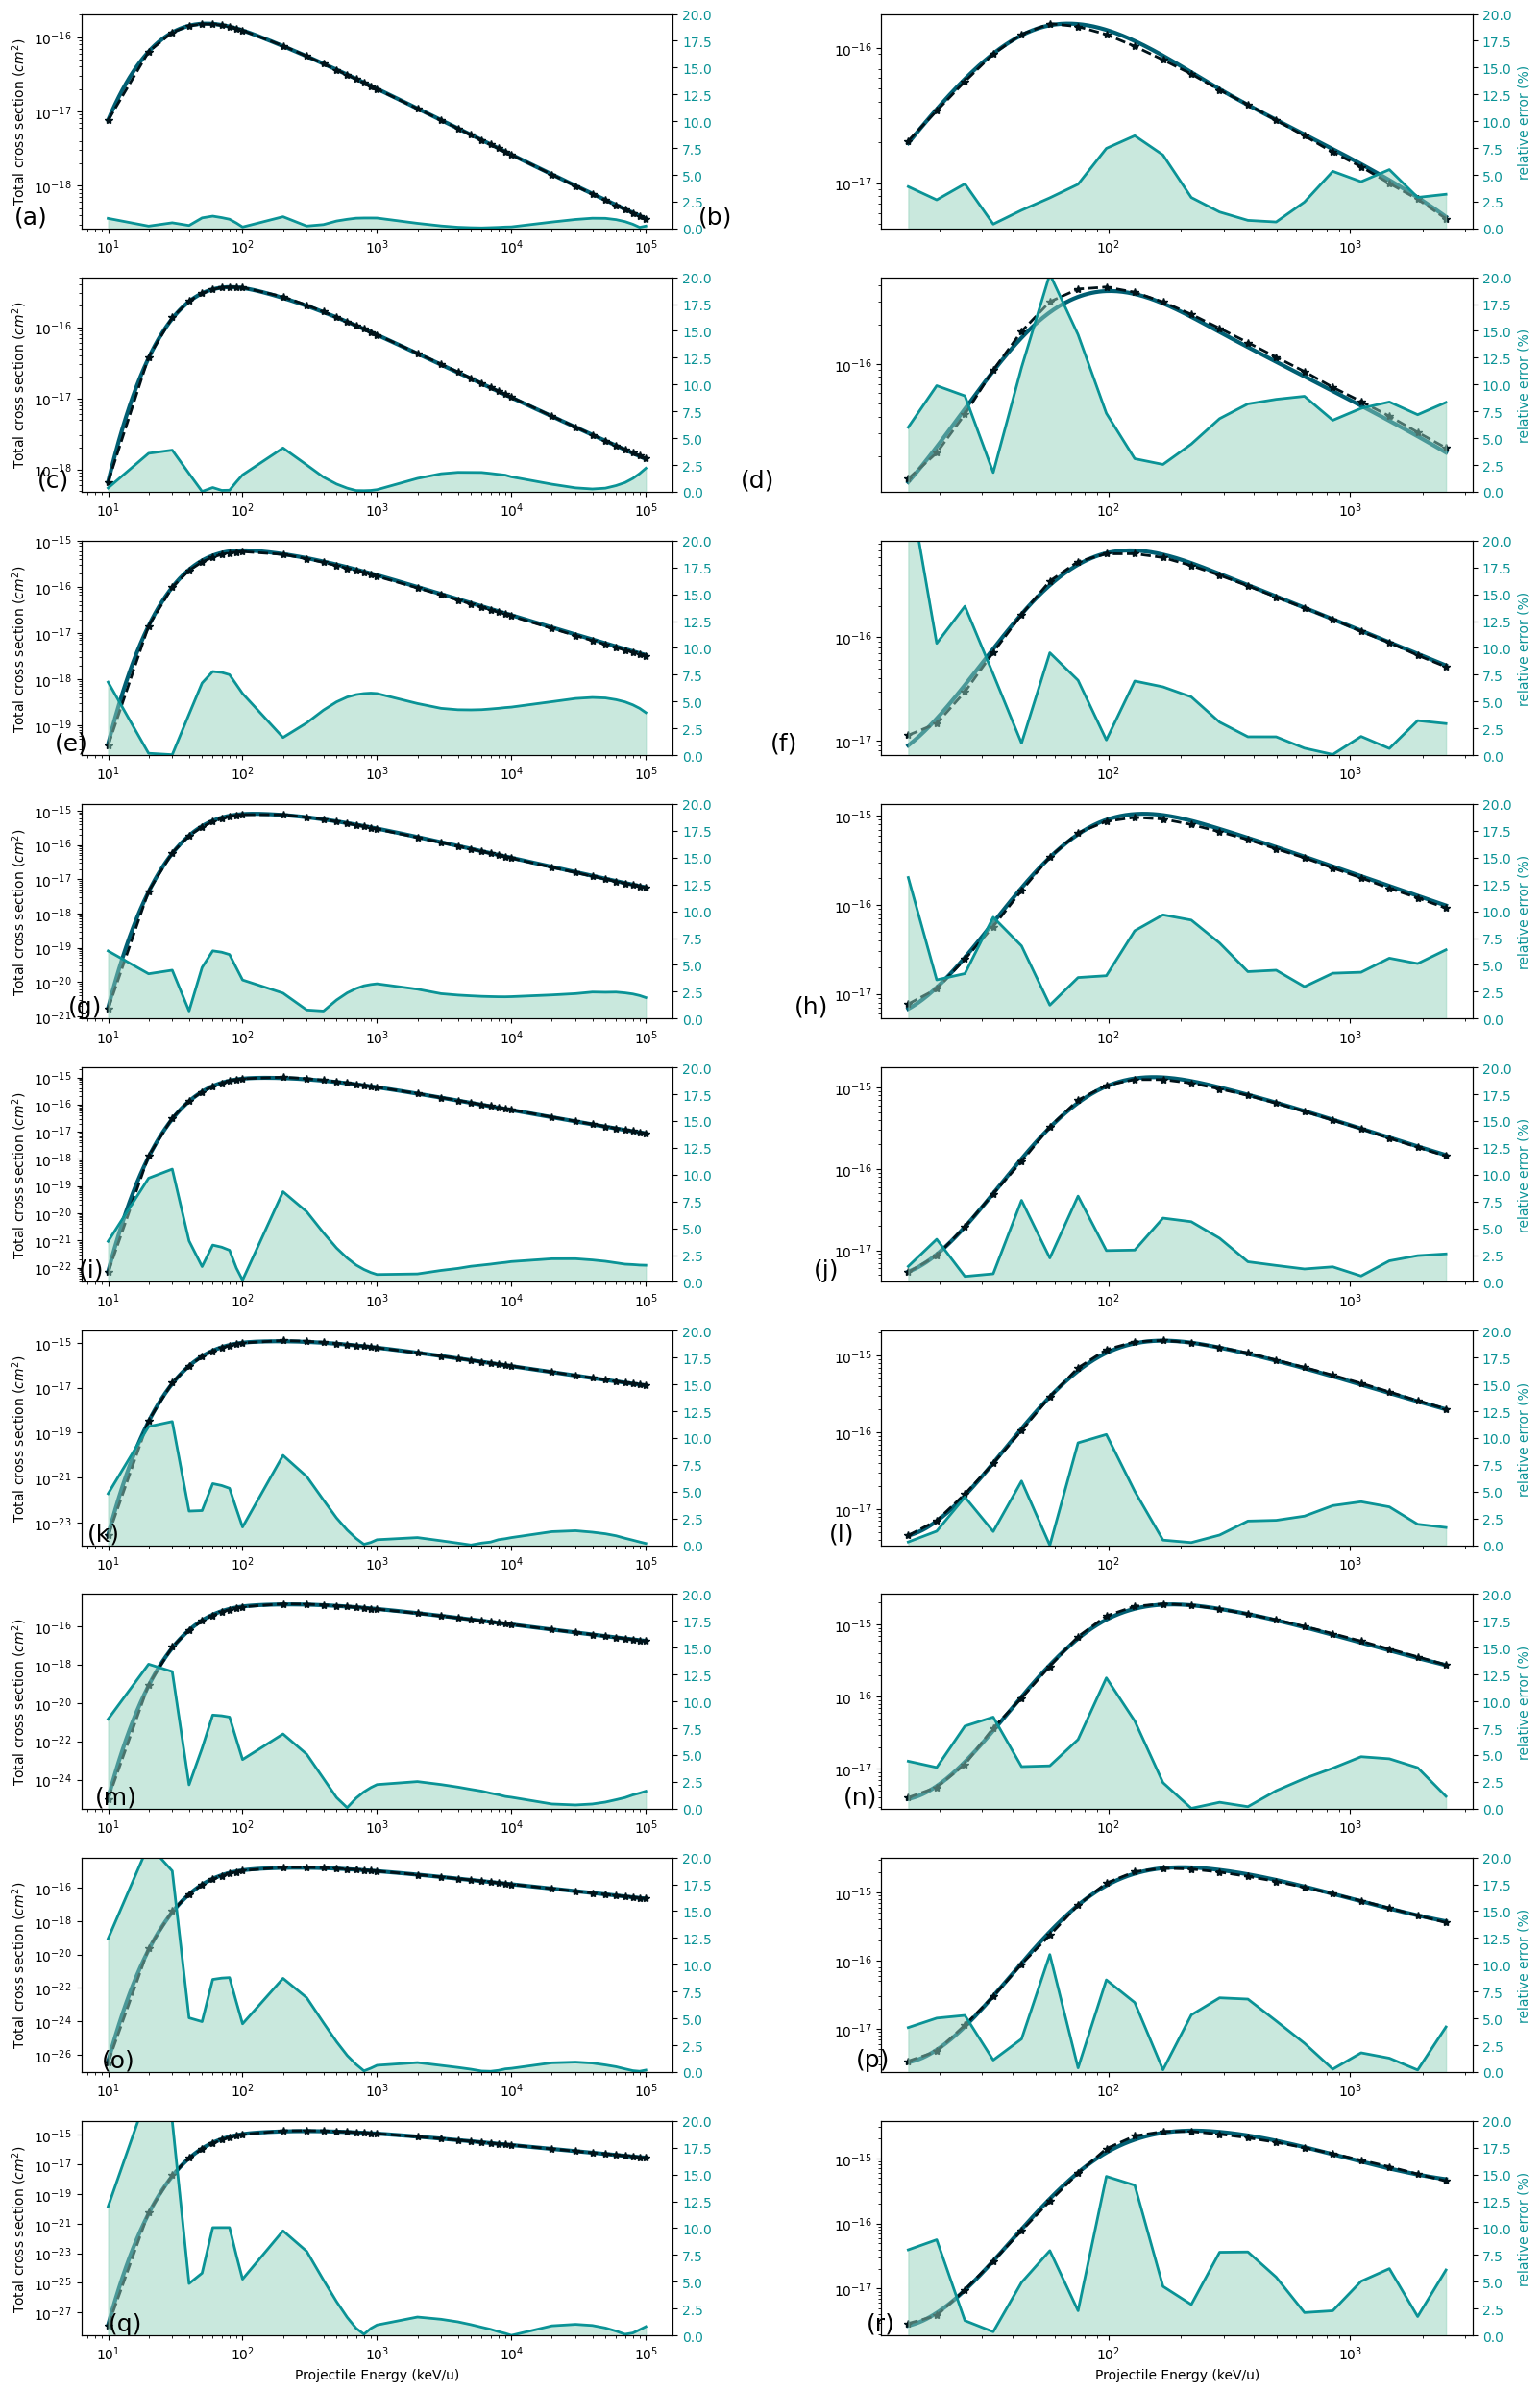

In [63]:
fig, axes = plt.subplots(9,2, figsize=(16, 25))

idx_row = 0
for z_ion in range(1,10):
    idx_col = 0
    for theory in ['CDW-EIS', 'CTMC']:
        aux = hyd_df[hyd_df['Theory_ID']==theory]
        aux = aux[aux['Z_ion']==z_ion]
        x_groundt = aux['Z_ion'].values
        y_groundt = np.log10(aux['E_proj[keV/u]'].values)
        z_groundt = np.log10(aux['Cross_section[cm2]'].values)

        # calculation of interpolations over training set
        z_pred = splines[theory](x_groundt, y_groundt, grid=False)

        # calculation over new points
        x_to_plot = np.ones(300)*z_ion
        y_to_plot = np.linspace(np.min(y_groundt),
                                        np.max(y_groundt),
                                        300)
        z_pred_to_plot = splines[theory](x_to_plot, y_to_plot, grid=False)
        error = rel_err(10**z_groundt, 10**z_pred)*100

        axes[idx_row,idx_col].loglog(10**y_to_plot, 10**z_pred_to_plot, lw = 3, 
                                        color= colorlist3[1], 
                                        label = f'MLP {theory}' )

        axes[idx_row,idx_col].loglog(10**y_groundt, 10**z_groundt, '*--', lw = 2, color= colorlist3[0],
                                        label = f'Theory {theory}' )

        ax_right = axes[idx_row,idx_col].twinx()
        ax_right.semilogx(10**y_groundt, error, c = colorlist3[2], lw = 2)
        ax_right.fill_between(10**y_groundt, error,color = colorlist3[3], alpha = 0.5)
        
        ax_right.tick_params(axis='y', labelcolor=colorlist3[2])
        ax_right.set_ylim(0,20)
        ax_right.text(x_groundt.min()+1, 0.5, labels_figs[idx_col+idx_row*2], fontsize=18)

        # axes[idx_row,idx_col].legend()
        idx_col += 1
    ax_right.set_ylabel('relative error (%)', color=colorlist3[2])
    axes[idx_row,0].set_ylabel(r'Total cross section ($cm^2$)' )
    idx_row +=1
axes[8,0].set_xlabel('Projectile Energy (keV/u)')
axes[8,1].set_xlabel('Projectile Energy (keV/u)')
fig.tight_layout()
plt.savefig('./performance_cubic.png')


# Bicubic splines (Holes $Z_P=\{3,4\}$)

In [74]:
from scipy.interpolate import SmoothBivariateSpline
# --- Data for the Conditional NN with Z_target = 1 ---
from db_reader import read_all_databases

namelist = [os.path.join('.','dbs','Semiempiric_db', 'semiempiric_TCS_database_single_ionization_atoms_1985Rudd.csv'),
            os.path.join('.','dbs','ctmc', 'ctmc_TCS_database_single_ionization_hydrogen.csv'),
            os.path.join('.','dbs','CDWEIS', 'cdw-eis_TCS_database_single_ionization_atoms_except_Kr.csv')]

df =read_all_databases(namelist)

# One-hot encode Theory_ID
# --- Data for the Conditional NN with Z_target = 1 ---

hyd_df = df[df['Z_target']==1]
theory_one_hot = encoder.transform(hyd_df[['Theory_ID']].values)
df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)

# Interpolation with bsplines
splines = {}
for theory in ['CDW-EIS', 'CTMC']:
    aux = hyd_df[hyd_df['Theory_ID']==theory]
    aux = aux[aux['Z_ion'] != 3]
    aux = aux[aux['Z_ion'] != 4]
    x_spline = aux['Z_ion'].values
    y_spline = np.log10(aux['E_proj[keV/u]'].values)
    z_spline = np.log10(aux['Cross_section[cm2]'].values)

    splines[theory] = SmoothBivariateSpline(x_spline, y_spline, z_spline, kx=3, ky=3, s=0.1)
    coeficientes = splines[theory].get_coeffs()
    n_total = coeficientes.size
    # 4. Ver los nudos (knots) que determinan el conteo
    nudos_x = splines[theory].get_knots()[0]
    nudos_y = splines[theory].get_knots()[1]

print(f"Nudos en X: {len(nudos_x)}, Nudos en Y: {len(nudos_y)}")
print(f"La cantidad de coeficientes es: {n_total}")

x_to_plot = np.ones(100)
y_to_plot = np.linspace(1,4,100)
z_to_plot = splines['CDW-EIS'](x_to_plot,y_to_plot, grid=False)

Nudos en X: 10, Nudos en Y: 11
La cantidad de coeficientes es: 42


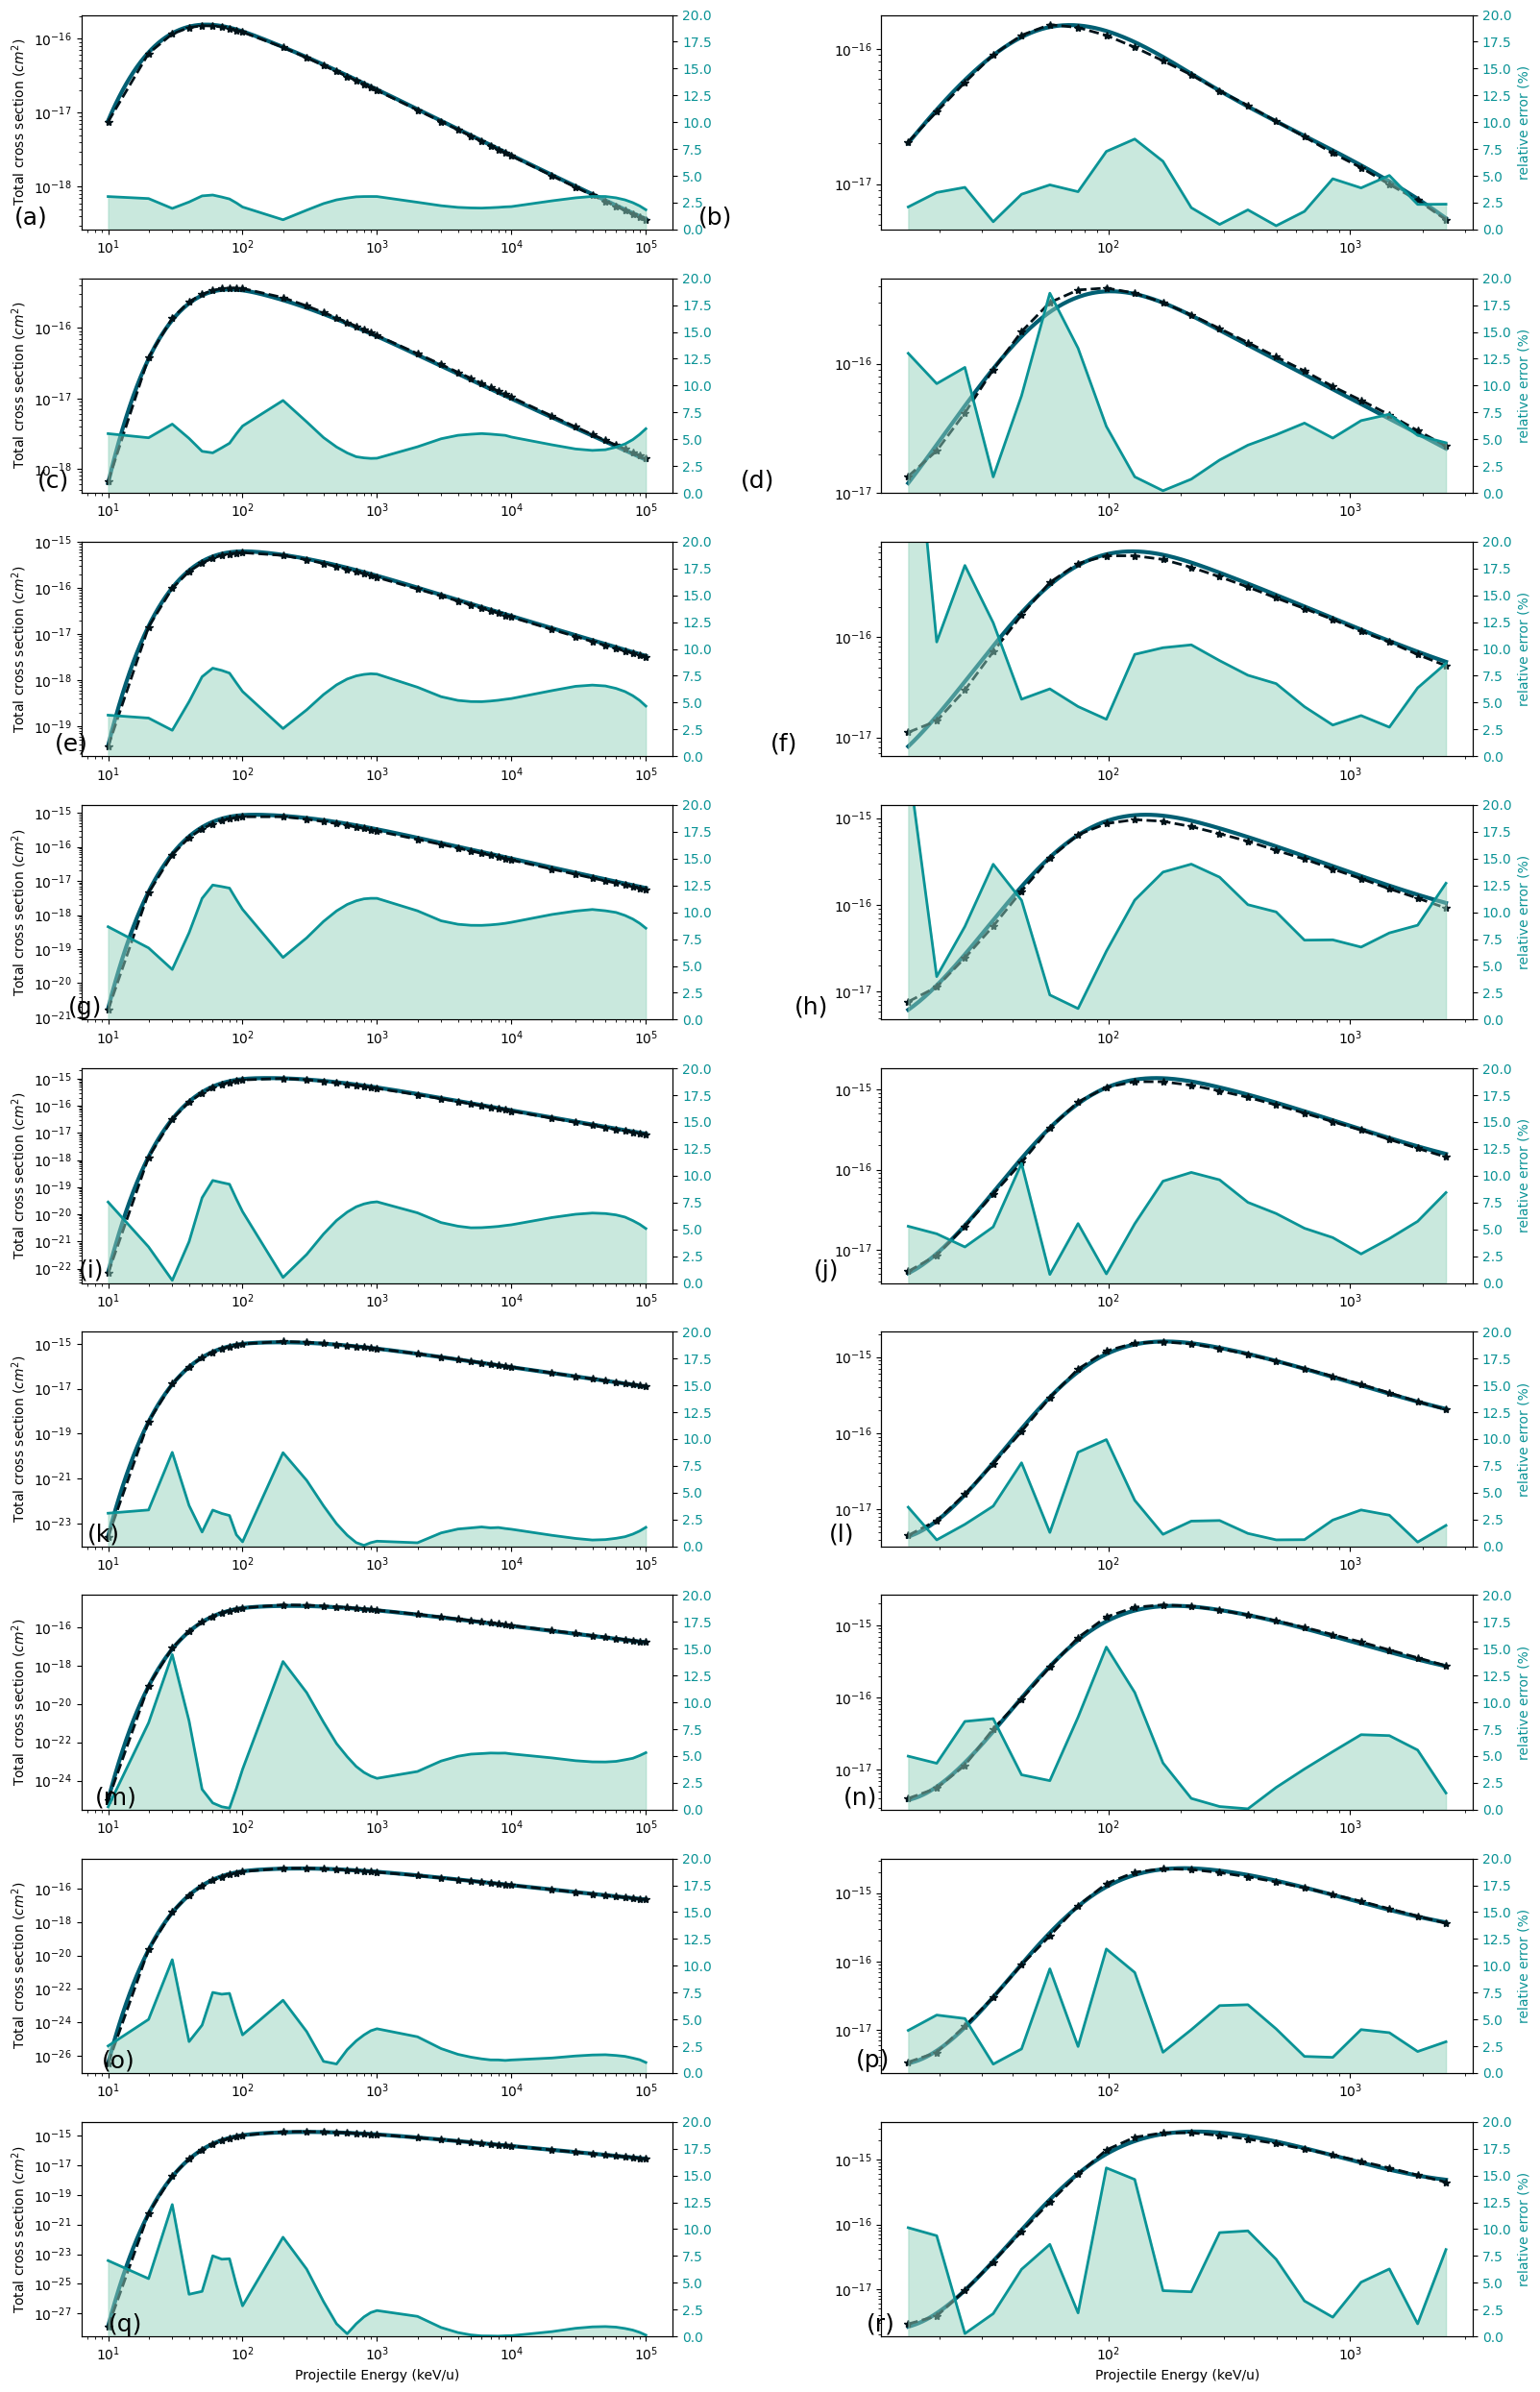

In [75]:
fig, axes = plt.subplots(9,2, figsize=(16, 25))

idx_row = 0
for z_ion in range(1,10):
    idx_col = 0
    for theory in ['CDW-EIS', 'CTMC']:
        aux = hyd_df[hyd_df['Theory_ID']==theory]
        aux = aux[aux['Z_ion']==z_ion]
        x_groundt = aux['Z_ion'].values
        y_groundt = np.log10(aux['E_proj[keV/u]'].values)
        z_groundt = np.log10(aux['Cross_section[cm2]'].values)

        # calculation of interpolations over training set
        z_pred = splines[theory](x_groundt, y_groundt, grid=False)

        # calculation over new points
        x_to_plot = np.ones(300)*z_ion
        y_to_plot = np.linspace(np.min(y_groundt),
                                        np.max(y_groundt),
                                        300)
        z_pred_to_plot = splines[theory](x_to_plot, y_to_plot, grid=False)
        error = rel_err(10**z_groundt, 10**z_pred)*100

        axes[idx_row,idx_col].loglog(10**y_to_plot, 10**z_pred_to_plot, lw = 3, 
                                        color= colorlist3[1], 
                                        label = f'MLP {theory}' )

        axes[idx_row,idx_col].loglog(10**y_groundt, 10**z_groundt, '*--', lw = 2, color= colorlist3[0],
                                        label = f'Theory {theory}' )

        ax_right = axes[idx_row,idx_col].twinx()
        ax_right.semilogx(10**y_groundt, error, c = colorlist3[2], lw = 2)
        ax_right.fill_between(10**y_groundt, error,color = colorlist3[3], alpha = 0.5)
        
        ax_right.tick_params(axis='y', labelcolor=colorlist3[2])
        ax_right.set_ylim(0,20)
        ax_right.text(x_groundt.min()+1, 0.5, labels_figs[idx_col+idx_row*2], fontsize=18)

        # axes[idx_row,idx_col].legend()
        idx_col += 1
    ax_right.set_ylabel('relative error (%)', color=colorlist3[2])
    axes[idx_row,0].set_ylabel(r'Total cross section ($cm^2$)' )
    idx_row +=1
axes[8,0].set_xlabel('Projectile Energy (keV/u)')
axes[8,1].set_xlabel('Projectile Energy (keV/u)')
fig.tight_layout()
plt.savefig('./performance_cubic.png')


# Extrapolation case (hole at $Z_P=9$)

Nudos en X: 10, Nudos en Y: 11
La cantidad de coeficientes es: 42


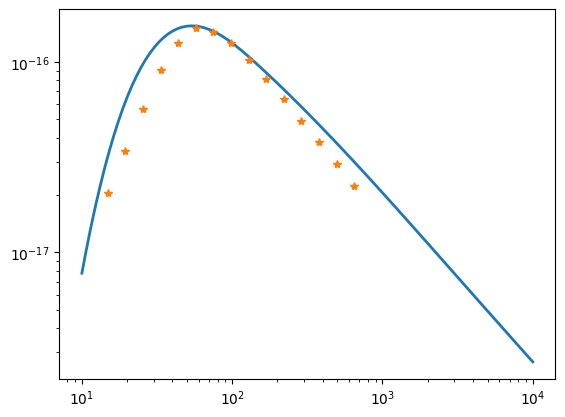

In [76]:
from scipy.interpolate import SmoothBivariateSpline
# --- Data for the Conditional NN with Z_target = 1 ---
from db_reader import read_all_databases

namelist = [os.path.join('.','dbs','Semiempiric_db', 'semiempiric_TCS_database_single_ionization_atoms_1985Rudd.csv'),
            os.path.join('.','dbs','ctmc', 'ctmc_TCS_database_single_ionization_hydrogen.csv'),
            os.path.join('.','dbs','CDWEIS', 'cdw-eis_TCS_database_single_ionization_atoms_except_Kr.csv')]

df =read_all_databases(namelist)

# One-hot encode Theory_ID
# --- Data for the Conditional NN with Z_target = 1 ---

hyd_df = df[df['Z_target']==1]
theory_one_hot = encoder.transform(hyd_df[['Theory_ID']].values)
df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)

# Interpolation with bsplines
splines = {}
for theory in ['CDW-EIS', 'CTMC']:
    aux = hyd_df[hyd_df['Theory_ID']==theory]
    aux = aux[aux['Z_ion'] != 9]
    x_spline = aux['Z_ion'].values
    y_spline = np.log10(aux['E_proj[keV/u]'].values)
    z_spline = np.log10(aux['Cross_section[cm2]'].values)

    splines[theory] = SmoothBivariateSpline(x_spline, y_spline, z_spline, kx=3, ky=3, s=0.1)
    coeficientes = splines[theory].get_coeffs()
    n_total = coeficientes.size
    # 4. Ver los nudos (knots) que determinan el conteo
    nudos_x = splines[theory].get_knots()[0]
    nudos_y = splines[theory].get_knots()[1]

print(f"Nudos en X: {len(nudos_x)}, Nudos en Y: {len(nudos_y)}")
print(f"La cantidad de coeficientes es: {n_total}")

x_to_plot = np.ones(100)
y_to_plot = np.linspace(1,4,100)
z_to_plot = splines['CDW-EIS'](x_to_plot,y_to_plot, grid=False)
plt.loglog(10**y_to_plot, 10**z_to_plot, '-', lw =2)
plt.loglog(10**y_spline[:15], 10**z_spline[:15], '*')


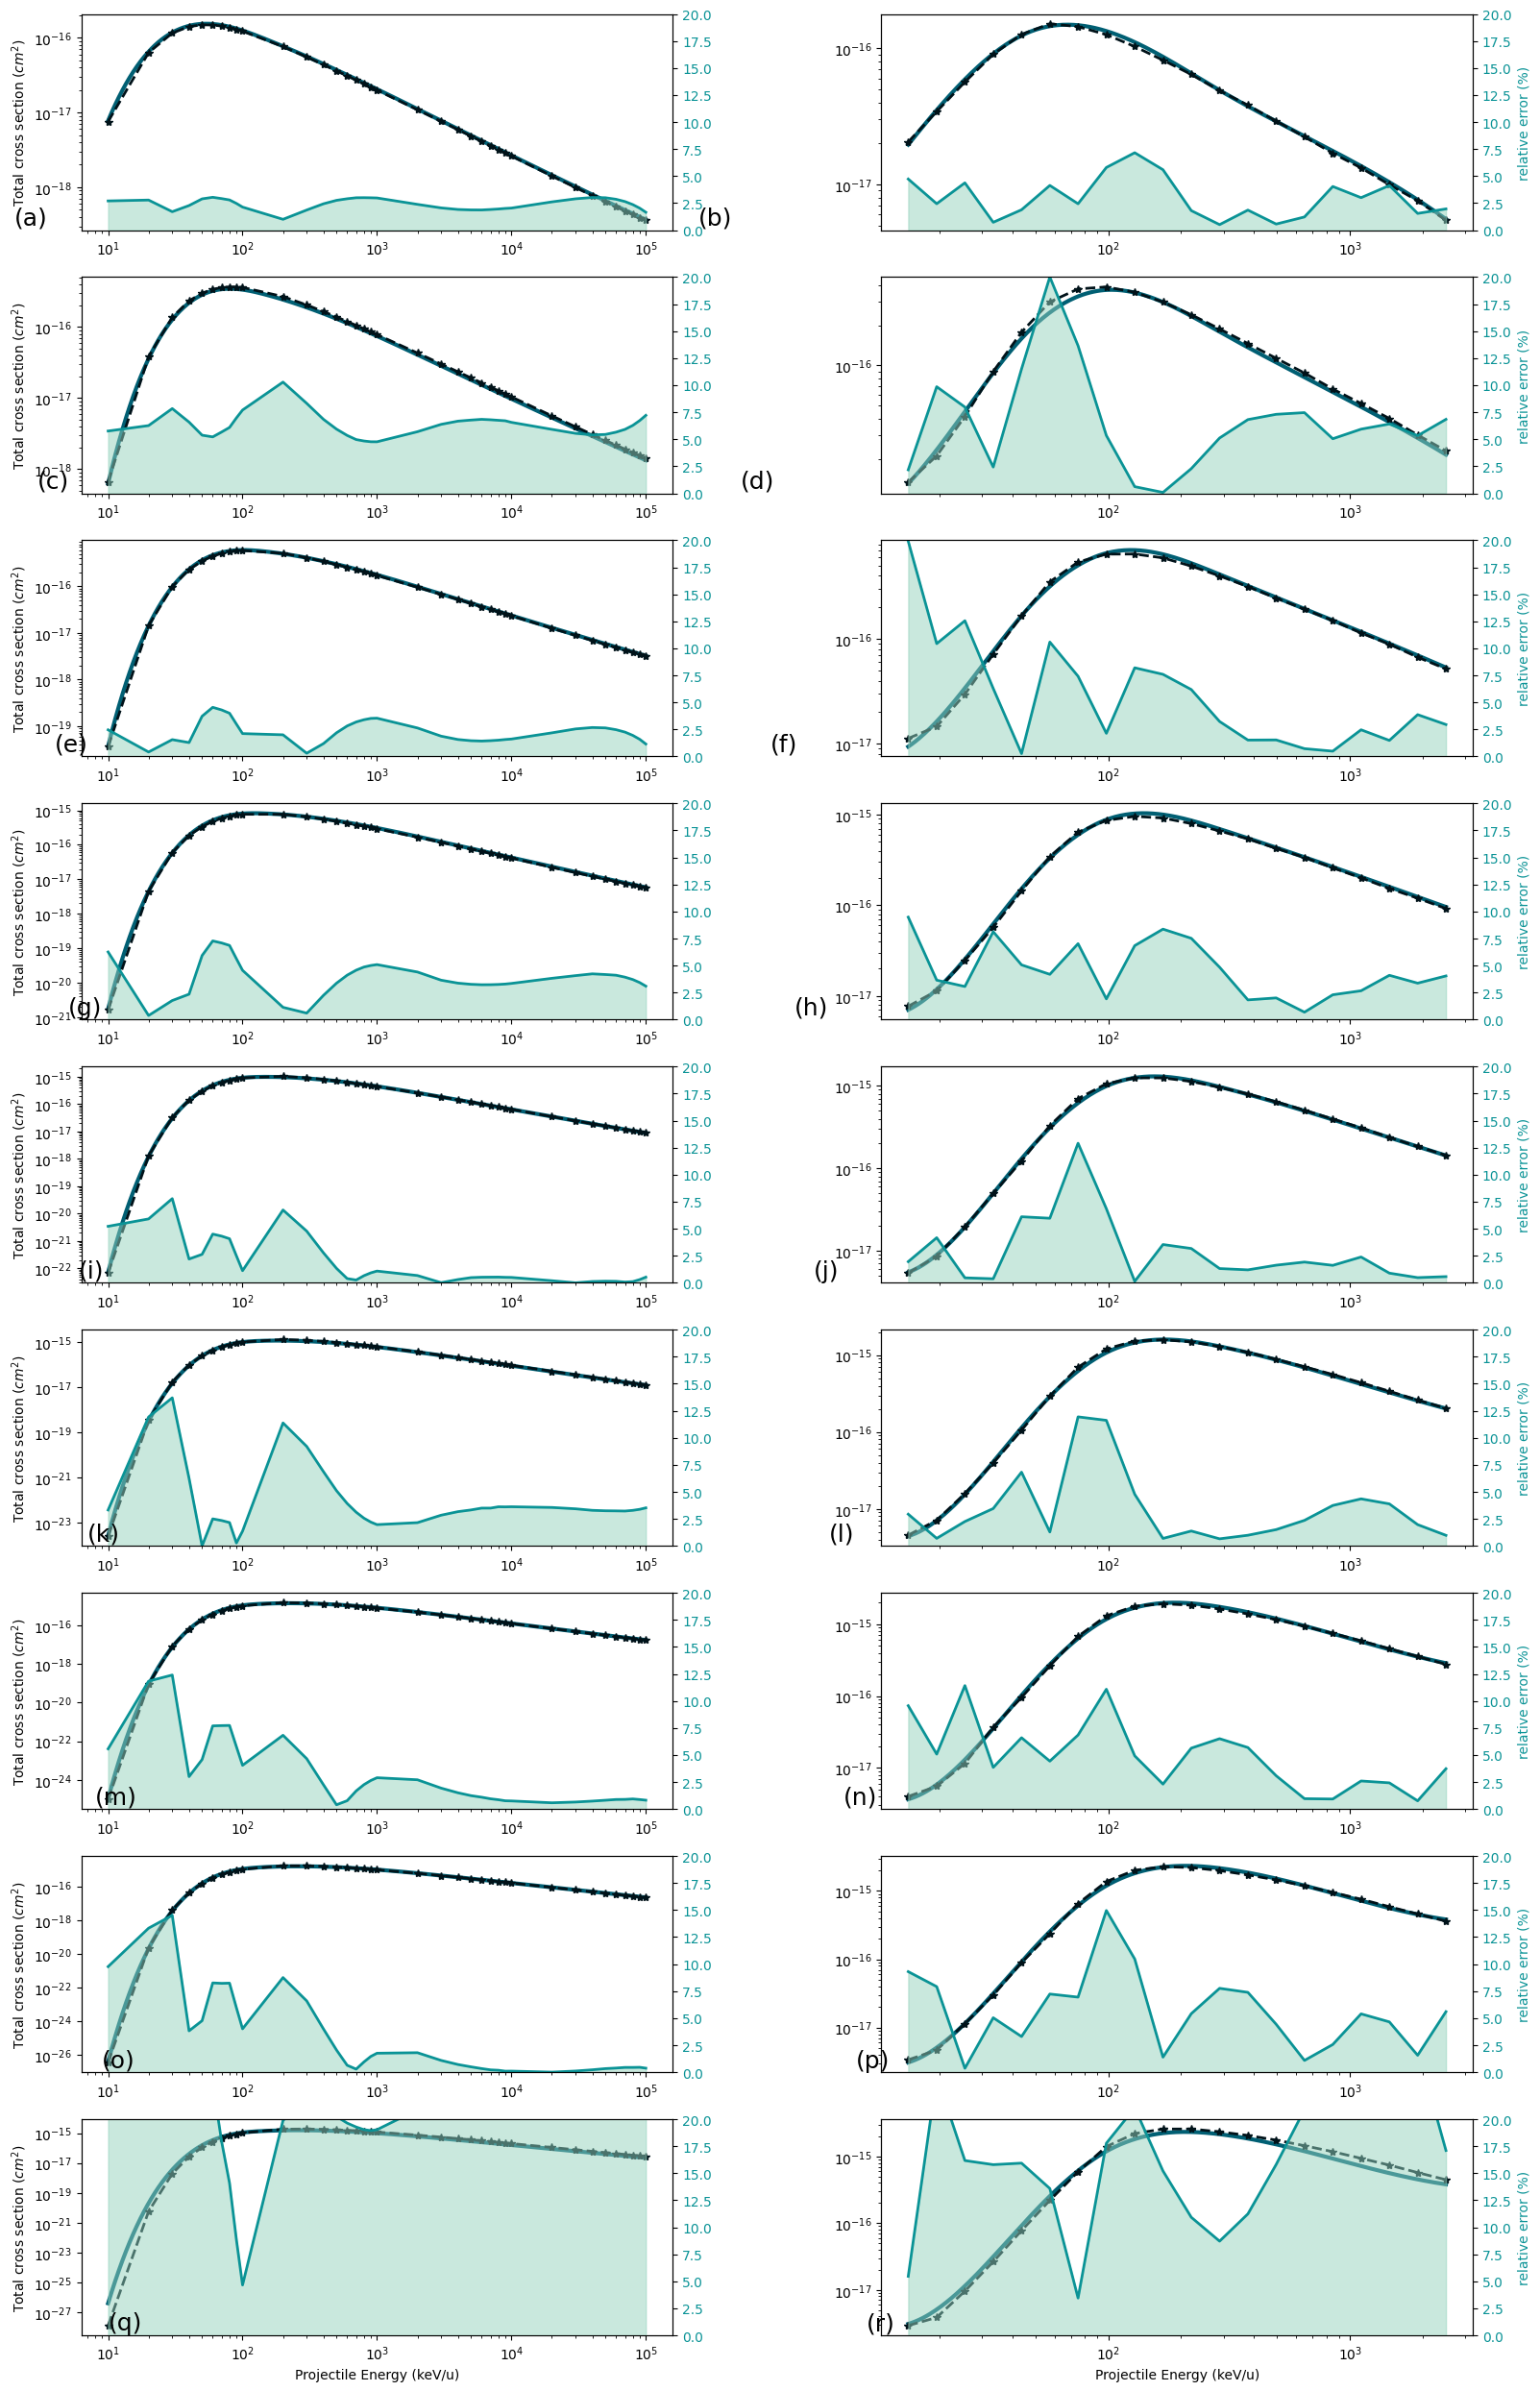

In [77]:
fig, axes = plt.subplots(9,2, figsize=(16, 25))

idx_row = 0
for z_ion in range(1,10):
    idx_col = 0
    for theory in ['CDW-EIS', 'CTMC']:
        aux = hyd_df[hyd_df['Theory_ID']==theory]
        aux = aux[aux['Z_ion']==z_ion]
        x_groundt = aux['Z_ion'].values
        y_groundt = np.log10(aux['E_proj[keV/u]'].values)
        z_groundt = np.log10(aux['Cross_section[cm2]'].values)

        # calculation of interpolations over training set
        z_pred = splines[theory](x_groundt, y_groundt, grid=False)

        # calculation over new points
        x_to_plot = np.ones(300)*z_ion
        y_to_plot = np.linspace(np.min(y_groundt),
                                        np.max(y_groundt),
                                        300)
        z_pred_to_plot = splines[theory](x_to_plot, y_to_plot, grid=False)
        error = rel_err(10**z_groundt, 10**z_pred)*100

        axes[idx_row,idx_col].loglog(10**y_to_plot, 10**z_pred_to_plot, lw = 3, 
                                        color= colorlist3[1], 
                                        label = f'MLP {theory}' )

        axes[idx_row,idx_col].loglog(10**y_groundt, 10**z_groundt, '*--', lw = 2, color= colorlist3[0],
                                        label = f'Theory {theory}' )

        ax_right = axes[idx_row,idx_col].twinx()
        ax_right.semilogx(10**y_groundt, error, c = colorlist3[2], lw = 2)
        ax_right.fill_between(10**y_groundt, error,color = colorlist3[3], alpha = 0.5)
        
        ax_right.tick_params(axis='y', labelcolor=colorlist3[2])
        ax_right.set_ylim(0,20)
        ax_right.text(x_groundt.min()+1, 0.5, labels_figs[idx_col+idx_row*2], fontsize=18)

        # axes[idx_row,idx_col].legend()
        idx_col += 1
    ax_right.set_ylabel('relative error (%)', color=colorlist3[2])
    axes[idx_row,0].set_ylabel(r'Total cross section ($cm^2$)' )
    idx_row +=1
axes[8,0].set_xlabel('Projectile Energy (keV/u)')
axes[8,1].set_xlabel('Projectile Energy (keV/u)')
fig.tight_layout()
plt.savefig('./performance_cubic.png')


model parameters: 17537

In [15]:
128*5+128+128*128+128*2+1

17409